<a href="https://colab.research.google.com/github/leandroabritez/AprP_tp2/blob/main/BRITEZ-LEANDRO-TP2-Co25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno :** Leandro Britez


# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.


# DESARROLLO

In [ ]:
# Librerías

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix,f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder


from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.callbacks import Callback


In [9]:
# Leo los CSV

pd.set_option('display.max_columns', None)

# Google Drive file ID from the provided link
file_id = '14NaASnZwTM2amJnMxz5E_6rczadZF4Zq'

# Output filename
output = 'adult_train.csv'

# Download the file
gdown.download(id=file_id, output=output, quiet=False)

# Read the downloaded CSV into a pandas DataFrame
df_train = pd.read_csv(output)

# Display the first few rows of the DataFrame
df_train

Downloading...
From: https://drive.google.com/uc?id=14NaASnZwTM2amJnMxz5E_6rczadZF4Zq
To: /content/adult_train.csv
100%|██████████| 3.77M/3.77M [00:00<00:00, 186MB/s]


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,tech_programming_basic,United-States,<=50K
30158,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,trade_welding,United-States,>50K
30159,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,trade_electrical,United-States,<=50K
30160,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,tech_computer_literacy,United-States,<=50K


In [10]:
# Google Drive file ID from the provided link
file_id = '1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN'

# Output filename
output = 'adult_val.csv'

# Download the file
gdown.download(id=file_id, output=output, quiet=False)

# Read the downloaded CSV into a pandas DataFrame
df_val = pd.read_csv(output)

# Display the first few rows of the DataFrame
df_val

Downloading...
From: https://drive.google.com/uc?id=1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN
To: /content/adult_val.csv
100%|██████████| 1.89M/1.89M [00:00<00:00, 97.6MB/s]


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,security_patrol_basic,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,trade_cnc_operation,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,transport_commercial_driving,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,personal_care_assistance,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15055,33,Private,Bachelors,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
15056,39,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,healthcare_medical_assistant,United-States,<=50K
15057,38,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,office_spreadsheets_basic,United-States,<=50K
15058,44,Private,Bachelors,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,office_data_entry_basic,United-States,<=50K


### **a) Análisis exploratorio de los datasets**

Primero, uniremos los datasets de entrenamiento y validación para realizar un EDA completo sobre el conjunto de datos.


In [11]:
df = pd.concat([df_train, df_val], ignore_index=True)
df

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,33,Private,Bachelors,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
45218,39,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,healthcare_medical_assistant,United-States,<=50K
45219,38,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,office_spreadsheets_basic,United-States,<=50K
45220,44,Private,Bachelors,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,office_data_entry_basic,United-States,<=50K


A continuación, mostraremos información general del dataset, incluyendo tipos de datos y valores no nulos.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   marital-status  45222 non-null  object
 4   occupation      45222 non-null  object
 5   relationship    45222 non-null  object
 6   race            45222 non-null  object
 7   sex             45222 non-null  object
 8   capital-gain    45222 non-null  int64 
 9   capital-loss    45222 non-null  int64 
 10  hours-per-week  45222 non-null  int64 
 11  skill-profile   45222 non-null  object
 12  native-country  45222 non-null  object
 13  income          45222 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.8+ MB


El conjunto no posee nulos. Ahora, identifiquemos las variables numéricas y categóricas para un análisis más profundo.

In [13]:
numerical_features = df.select_dtypes(include=['int64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables Numéricas: {numerical_features}")
print(f"Variables Categóricas: {categorical_features}")

Variables Numéricas: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
Variables Categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'skill-profile', 'native-country', 'income']


### Análisis de Variables Categóricas

Analizaremos los valores únicos y la cardinalidad de cada variable categórica para determinar la estrategia de codificación más adecuada. Recordamos que una variable de alta cardinalidad tiene 10 o más valores únicos.


In [14]:
data = []
for col in categorical_features:
    unique_values = df[col].unique()
    cardinality = len(unique_values)
    data.append({
        "Variable": col,
        "Cardinalidad": cardinality,
        "Tipo": "Alta Cardinalidad" if cardinality >= 10 else "Baja Cardinalidad"
    })
df_cardinalidad = pd.DataFrame(data)
df_cardinalidad

,Variable,Cardinalidad,Tipo
0,workclass,7,Baja Cardinalidad
1,education,16,Alta Cardinalidad
2,marital-status,7,Baja Cardinalidad
3,occupation,14,Alta Cardinalidad
4,relationship,6,Baja Cardinalidad
5,race,5,Baja Cardinalidad
6,sex,2,Baja Cardinalidad
7,skill-profile,80,Alta Cardinalidad
8,native-country,41,Alta Cardinalidad
9,income,2,Baja Cardinalidad


In [15]:
# describimos los valores de las categóricas que puedan ser ordinales

for col in categorical_features:
    print(f"Columna: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 50)

Columna: workclass
workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64
--------------------------------------------------
Columna: education
education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64
--------------------------------------------------
Columna: marital-status
marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           3

#### Distribución de las Variables Categóricas (Gráficas de Torta)

A continuación se visualizan las distribuciones de las variables categóricas excluyendo la variable target `income`:

- **Baja cardinalidad** (< 10 valores únicos): torta completa con todos sus valores.
- **Alta cardinalidad** (≥ 10 valores únicos): torta con los **Top 5** valores más frecuentes y el resto agrupado en **'Otras'**.


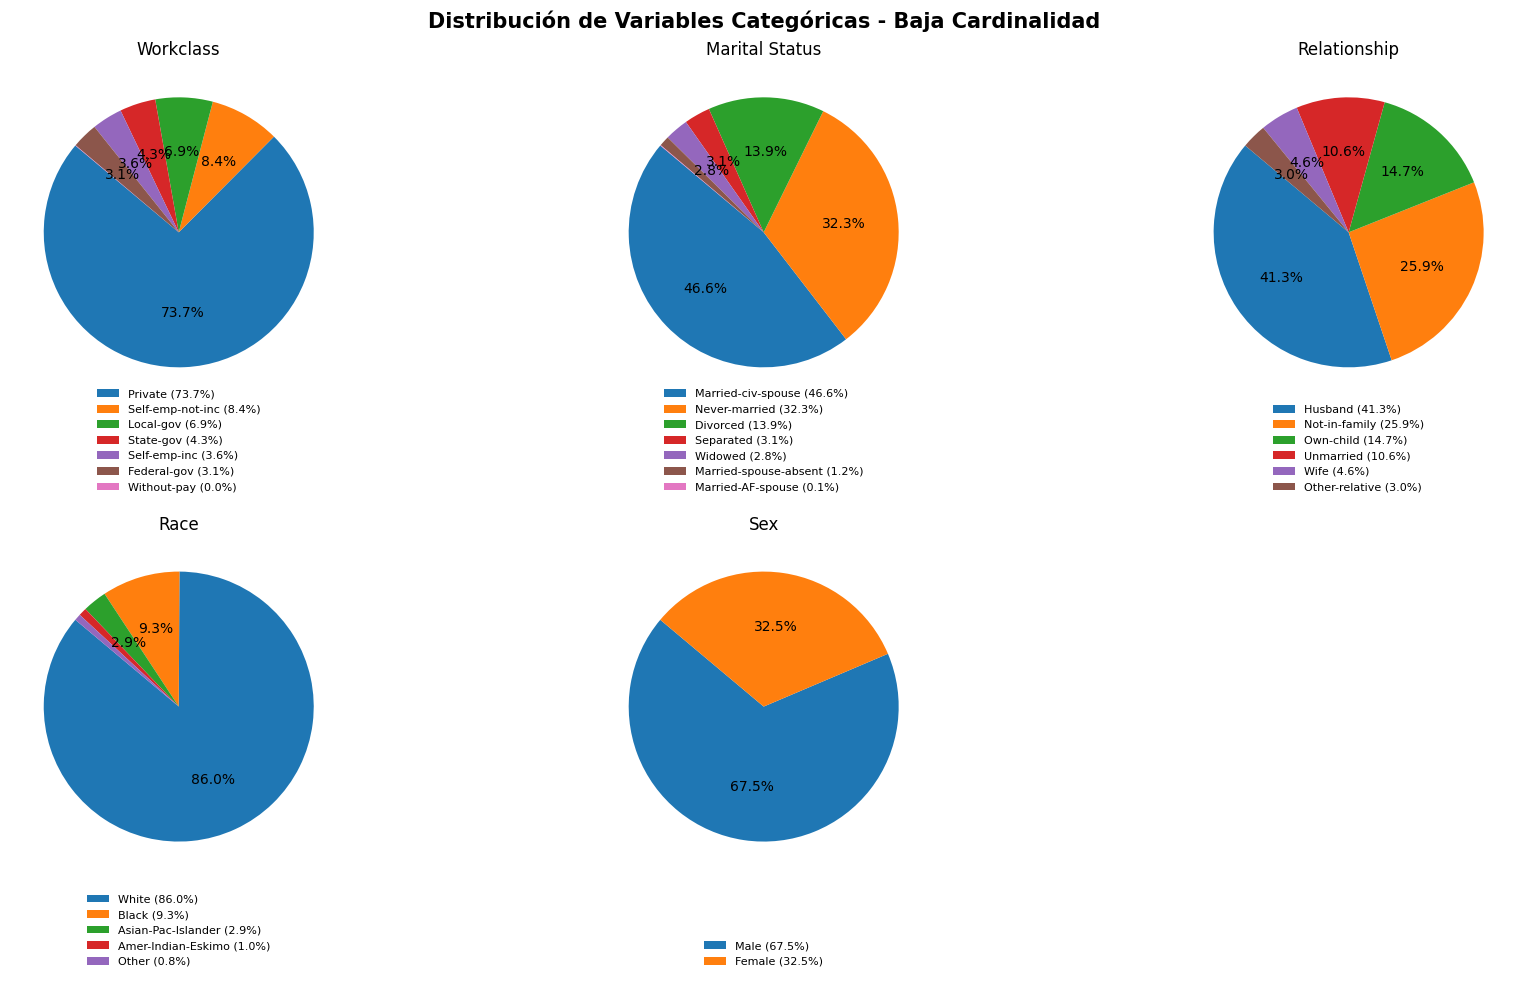

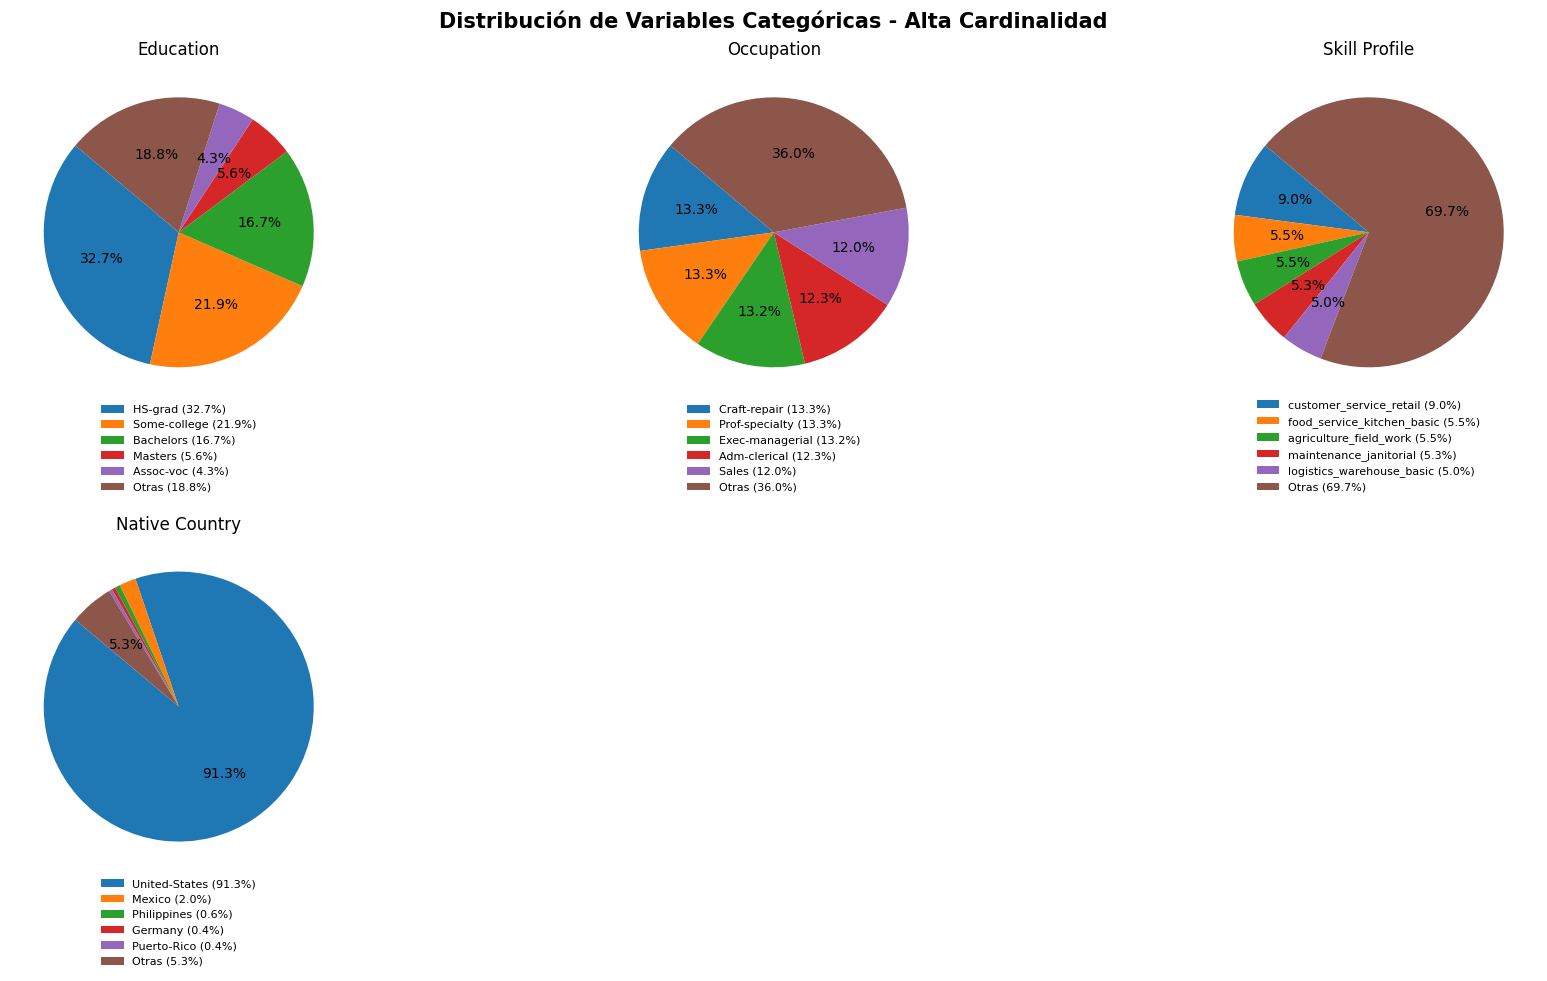

Variables de baja cardinalidad: ['workclass', 'marital-status', 'relationship', 'race', 'sex']
Variables de alta cardinalidad: ['education', 'occupation', 'skill-profile', 'native-country']


In [16]:
# Variables categóricas (sin la variable objetivo)
cat_vars = [c for c in categorical_features if c != "income"]

for alta_card, titulo in [(False, "Baja Cardinalidad"), (True, "Alta Cardinalidad")]:

    columnas = [c for c in cat_vars if (df[c].nunique() >= 10) == alta_card]

    filas = (len(columnas) + 2) // 3
    fig, axes = plt.subplots(filas, 3, figsize=(18, filas * 5))

    if len(columnas) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    fig.suptitle(f"Distribución de Variables Categóricas - {titulo}",
                 fontsize=15, fontweight="bold")

    for ax, col in zip(axes, columnas):

        conteo = df[col].value_counts()

        # Para alta cardinalidad mostrar Top 5 + Otras
        if alta_card:
            top = conteo.head(5)
            otras = conteo.iloc[5:].sum()

            etiquetas = top.index.tolist()
            valores = top.values.tolist()

            if otras > 0:
                etiquetas.append("Otras")
                valores.append(otras)
        else:
            etiquetas = conteo.index.tolist()
            valores = conteo.values.tolist()

        ax.pie(
            valores,
            labels=None,
            autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
            startangle=140
        )

        porcentajes = [v / sum(valores) * 100 for v in valores]

        ax.legend(
            [f"{e} ({p:.1f}%)" for e, p in zip(etiquetas, porcentajes)],
            loc="lower center",
            bbox_to_anchor=(0.5, -0.30),
            fontsize=8,
            frameon=False
        )

        ax.set_title(col.replace("-", " ").title())

    # Ocultar ejes vacíos
    for ax in axes[len(columnas):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

print("Variables de baja cardinalidad:",
      [c for c in cat_vars if df[c].nunique() < 10])

print("Variables de alta cardinalidad:",
      [c for c in cat_vars if df[c].nunique() >= 10])

El campo native country que tiene alta cardinalidad, concentra más del 90% de los registros en un único país (USA), generando que pueda ser poco útil para discriminar la variable objetivo pero no despreciable.

### Análisis de Variables Numéricas

Exploraremos la distribución de las variables numéricas a través de estadísticas descriptivas y visualizaciones.


,age,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1101.430344,88.595418,40.938017
std,13.217870,7506.430084,404.956092,12.007508
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


/tmp/ipykernel_1354/3420274543.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


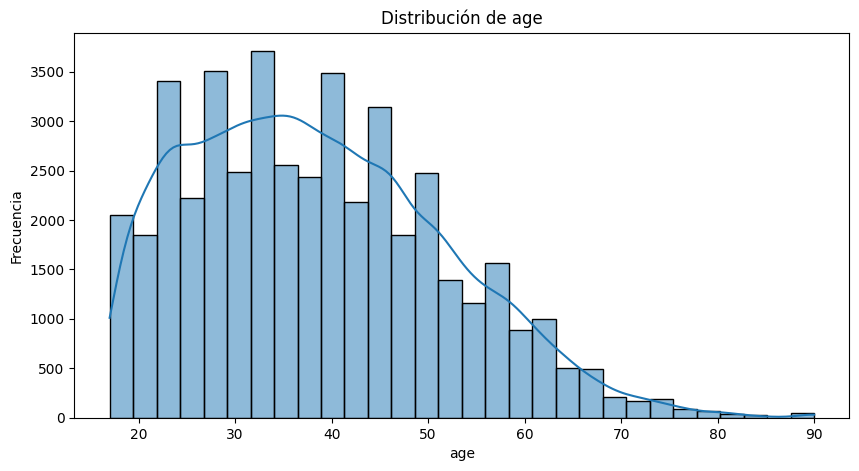

/tmp/ipykernel_1354/3420274543.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


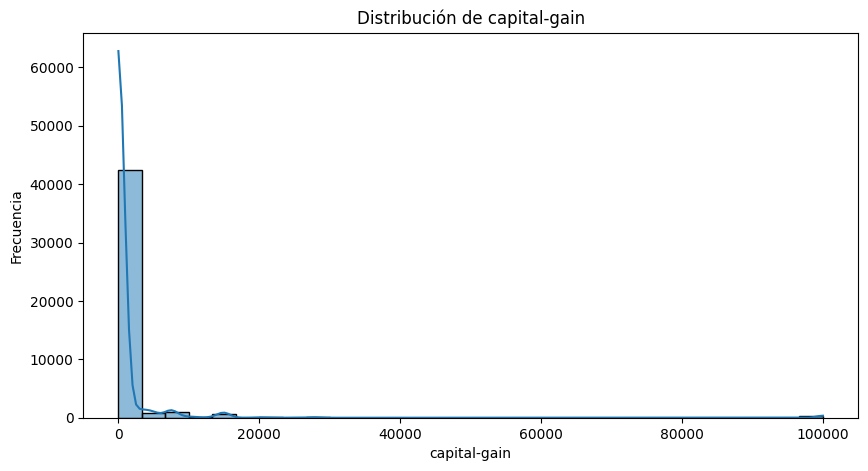

/tmp/ipykernel_1354/3420274543.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


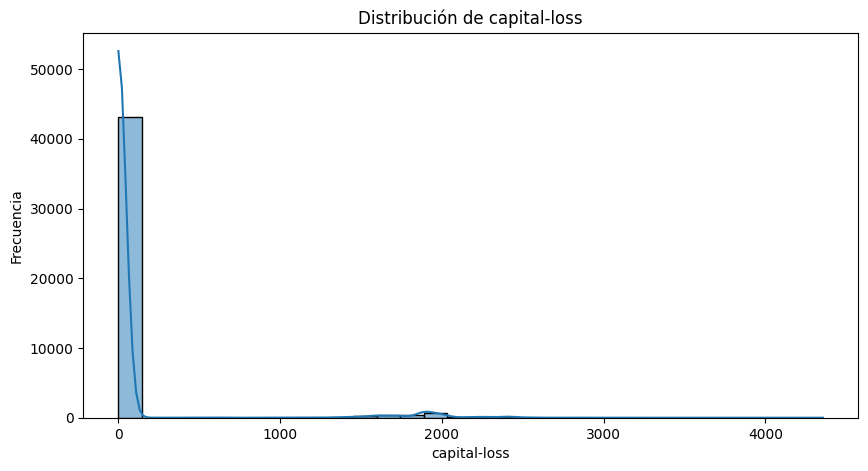

/tmp/ipykernel_1354/3420274543.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


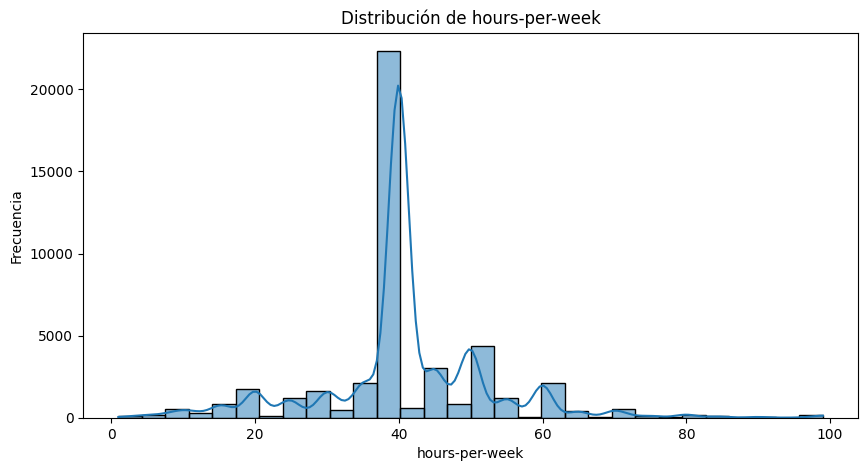

In [17]:
display(df[numerical_features].describe())

for col in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()



Se observa que para los campos capital-gain y capital-loss, concentran una alta cantidad de registros no nulos de valor cero, que revisameros porcentualmente a continuación, para tomar la desición de incluir o no dichas variables en el datarset a entrenar.

In [18]:
for col in ["capital-gain", "capital-loss"]:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"{col}: {zeros} valores = 0  ({pct:.2f}% del total)")

capital-gain: 41432 valores = 0  (91.62% del total)
capital-loss: 43082 valores = 0  (95.27% del total)


No son valores faltantes ni ruido — el cero significa literalmente "no tuvo ganancias/pérdidas de capital", lo cual es informativo.

### Análisis de la Variable Objetivo (`income`)

Examinaremos la distribución de la variable objetivo para entender el balance de clases.


/tmp/ipykernel_1354/1236597439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='viridis')


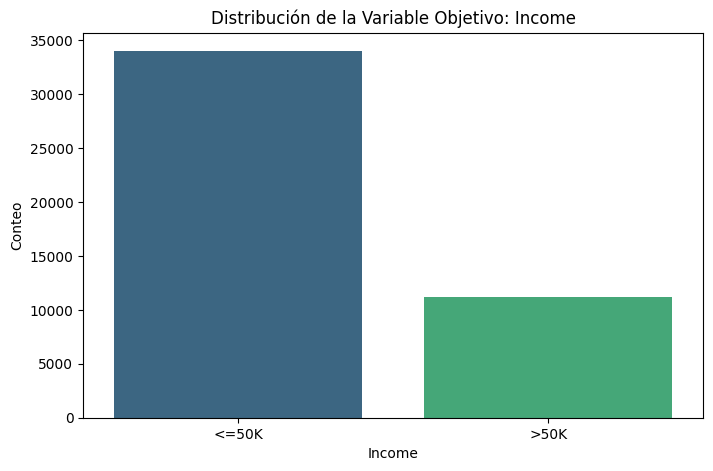

Distribución de la variable 'income':
income
<=50K    34014
>50K     11208
Name: count, dtype: int64
Proporción de '>50K': 24.78%
Proporción de '<=50K': 75.22%


In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='income', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo: Income')
plt.xlabel('Income')
plt.ylabel('Conteo')
plt.show()

income_counts = df['income'].value_counts()
print("Distribución de la variable 'income':")
print(income_counts)
print(f"Proporción de '>50K': {income_counts['>50K'] / len(df) * 100:.2f}%")
print(f"Proporción de '<=50K': {income_counts['<=50K'] / len(df) * 100:.2f}%")

Se observa el un desabalance de la variable objetivo de 3 a 1 para los casos donde income es <=50K

### Justificación de Transformaciones para Variables Categóricas

Basado en el análisis de cardinalidad y el contexto de cada variable, proponemos las siguientes transformaciones:

*   **`workclass`**: Baja cardinalidad (9 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`education`**: Alta cardinalidad (16 valores únicos), pero con un orden implícito (desde preescolar hasta doctorado). **Ordinal Encoding**.

*   **`marital-status`**: Baja cardinalidad (7 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`occupation`**: Alta cardinalidad (15 valores únicos). No hay un orden intrínseco claro. Dado que tiene una cardinalidad intermedia y podría beneficiarse de capturar relaciones semánticas, consideraremos **Embeddings** para esta variable en el modelo avanzado.

*   **`relationship`**: Baja cardinalidad (6 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`race`**: Baja cardinalidad (5 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`sex`**: Baja cardinalidad (2 valores únicos). **One-Hot Encoding** (o Label Encoding, ya que solo hay dos clases, pero One-Hot es más generalizable).

*   **`skill-profile`**: Alta cardinalidad (56 valores únicos). Es una variable descriptiva de habilidades. La alta cardinalidad y la naturaleza de las categorías sugieren que **Embeddings** podrían ser beneficiosos para capturar relaciones latentes entre diferentes perfiles de habilidades.

*   **`native-country`**: Alta cardinalidad (42 valores únicos). Representa países. Dada su alta cardinalidad y la posible diversidad geográfica y cultural que podría influir en los ingresos, Los **Embeddings** permiten que la red neuronal aprenda representaciones densas de las categorías. Si existen patrones latentes entre países relacionados con la variable objetivo, la red puede capturarlos durante el entrenamiento.

*   **`income` (Target)**: Variable binaria (<=50K, >50K). Se transformará a **numérica (0 o 1)** para el modelo de clasificación.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## Implementación de las transformaciones

En el punto anterior se definió el tipo de transformación más apropiado para cada variable categórica según su cardinalidad y naturaleza. En esta etapa se implementan dichas transformaciones respetando las decisiones adoptadas durante el EDA.

Dado que el dataset utilizado para el análisis exploratorio surge de la unión de df_train y df_val, se decidió generar una nueva partición entrenamiento-validación mediante train_test_split con muestreo estratificado sobre la variable objetivo. Esta estrategia permite mantener la distribución de clases y realizar todas las transformaciones exclusivamente sobre el conjunto de entrenamiento, evitando data leakage.

In [20]:
# separar X e y
X = df.drop('income', axis=1)
y = df['income']

# Label Encoding para la variable objetivo 'income'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Características para One-Hot Encoding (baja cardinalidad nominal sin orden)
one_hot_features = ['workclass', 'marital-status', 'relationship', 'race', 'sex']

# Características para Ordinal Encoding (con orden intrínseco)
ordinal_features = ['education']

# Definir el orden para OrdinalEncoder para 'education'
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

# Características para Embeddings (alta cardinalidad nominal)
embedding_features = ['occupation', 'skill-profile', 'native-country']


In [21]:
# Primero separar los datos en conjuntos de Train y Test para evitar Data Leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Crear preprocesadores para diferentes tipos de características
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_features),
        ('cat_ordinal', OrdinalEncoder(categories=[education_order]), ordinal_features)
    ],
    remainder='drop'
)

Para evitar data leakage, el ColumnTransformer se ajusta únicamente con el conjunto de entrenamiento (fit) y posteriormente se aplica al conjunto de validación (transform).

Las variables destinadas a embeddings no se transforman mediante One-Hot Encoding ni Ordinal Encoding, ya que serán procesadas directamente por las capas Embedding del modelo.

In [22]:
# Ajustar el preprocesador ÚNICAMENTE con los datos de entrenamiento y transformar ambos conjuntos
X_train_processed_array = preprocessor.fit_transform(X_train_raw)
X_test_processed_array = preprocessor.transform(X_test_raw)

# Obtener los nombres de las columnas resultantes del ColumnTransformer
onehot_feature_names = preprocessor.named_transformers_['cat_onehot'].get_feature_names_out(one_hot_features)
processed_column_names = numerical_features + onehot_feature_names.tolist() + ordinal_features

# Crear DataFrames para las características preprocesadas de train y test (respetando los índices originales)
X_train_processed = pd.DataFrame(X_train_processed_array, columns=processed_column_names, index=X_train_raw.index)
X_test_processed = pd.DataFrame(X_test_processed_array, columns=processed_column_names, index=X_test_raw.index)

# Separar y copiar las características de embeddings en crudo
X_train_embeddings = X_train_raw[embedding_features].copy()
X_test_embeddings = X_test_raw[embedding_features].copy()

# Concatenar las numéricas/OHE/Ordinal con los embeddings
X_train = pd.concat([X_train_processed, X_train_embeddings], axis=1)
X_test = pd.concat([X_test_processed, X_test_embeddings], axis=1)

display(X_train.head())
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

,age,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,education,occupation,skill-profile,native-country
11772,-1.407366,-0.147126,-0.220402,-0.497762,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,9.0,Sales,automotive_repair,United-States
22476,-0.952599,-0.147126,-0.220402,3.086839,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,9.0,Farming-fishing,logistics_warehouse_basic,United-States
17763,0.411699,-0.147126,-0.220402,-0.080948,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,4.0,Machine-op-inspct,logistics_warehouse_basic,United-States
22789,-0.649422,-0.147126,-0.220402,-0.080948,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,8.0,Adm-clerical,agriculture_field_work,United-States
26558,-0.573628,-0.147126,-0.220402,-0.080948,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,8.0,Farming-fishing,transport_commercial_driving,Ireland


Shape of X_train: (36177, 35)
Shape of X_test: (9045, 35)
Shape of y_train: (36177,)
Shape of y_test: (9045,)


## Definición de la arquitectura del modelo

Una vez preparados los datos, se define la arquitectura de la red neuronal.

Las variables numéricas, las variables codificadas mediante One-Hot Encoding y la variable ordinal constituyen una entrada densa tradicional.

En cambio, cada variable seleccionada para embeddings posee una entrada independiente que alimenta una capa Embedding. Posteriormente todas las representaciones se concatenan para conformar el vector de entrada completo de la red.

No existe una regla exacta para determinar la dimensión óptima de un embedding. En este trabajo se utilizó la heurística :

$ min(50,(N° cardinalidad+1)//2) $

ya que genera representaciones compactas para variables de cardinalidad intermedia, evitando un crecimiento alto del número de parámetros entrenables.

In [23]:
# Codificadores para las variables de embedding
embedding_encoders = {}
embedding_input_dims = {}
embedding_output_dims = {}

for col in embedding_features:
    # categorías del set de entrenamiento
    unique_cats = X_train[col].unique()
    num_unique = len(unique_cats)

    # OrdinalEncoder
    encoder = OrdinalEncoder(
        categories=[unique_cats],
        handle_unknown='use_encoded_value',
        unknown_value=num_unique
    )
    encoder.fit(X_train[[col]])
    embedding_encoders[col] = encoder

    # El tamaño del vocabulario será num_unique + 1 (para acomodar el valor desconocido si se presenta en validación)
    embedding_input_dims[col] = num_unique + 1
    # Dimensión del embedding
    embedding_output_dims[col] = min(50, (num_unique + 1) // 2)
    print(f"Feature: {col}, Unique values in train: {num_unique}, Embedding input dim: {embedding_input_dims[col]}, Embedding output dim: {embedding_output_dims[col]}")




Feature: occupation, Unique values in train: 14, Embedding input dim: 15, Embedding output dim: 7
Feature: skill-profile, Unique values in train: 80, Embedding input dim: 81, Embedding output dim: 40
Feature: native-country, Unique values in train: 41, Embedding input dim: 42, Embedding output dim: 21


In [24]:
# Entradas para el modelo
inputs = []

# Entrada para características numéricas y categóricas preprocesadas (OHE + Ordinal)
num_features_count = len(numerical_features) + len(onehot_feature_names) + len(ordinal_features)
numerical_categorical_input = keras.Input(shape=(num_features_count,), name='num_cat_input')
inputs.append(numerical_categorical_input)

# Entradas y capas de embedding para cada columna de alta cardinalidad
embedding_layers = []
for col in embedding_features:

    input_layer = keras.Input(shape=(1,), name=f'{col}_input')
    inputs.append(input_layer)

    embedding_layer = layers.Embedding(
        input_dim=embedding_input_dims[col],
        output_dim=embedding_output_dims[col],
        name=f'{col}_embedding'
    )(input_layer)
    # Redimensionar salida a 2D
    embedding_layer = layers.Flatten()(embedding_layer)
    embedding_layers.append(embedding_layer)

# Concatenar todas las entradas
all_features = layers.concatenate([numerical_categorical_input] + embedding_layers)



Se usan dos capas densas de 128 y 64 neuronas con activación ReLU, para aprender relaciones no lineales entre las variables de entrada.

Entre ambas capas se utiliza un dropout del 30%, con el objetivo de disminuir el riesgo de sobreajuste durante el entrenamiento.

In [25]:
# Construir el resto del modelo (con regularización dropout según consigna)
x = layers.Dense(128, activation='relu')(all_features)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Crear el modelo
model_with_embeddings = Model(inputs=inputs, outputs=output_layer)

# Compilar el modelo
model_with_embeddings.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar el resumen del modelo
model_with_embeddings.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ occupation_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill-profile_input │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ native-country_inp… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ occupation_embeddi… │ (None, 1, 7)      │        105 │ occupation_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill-profile_embe… │ (None, 1, 40)     │      3,240 │ skill-profile_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ native-country_emb… │ (None, 1, 21)     │        882 │ native-country_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_cat_input       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7)         │          0 │ occupation_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 40)        │          0 │ skill-profile_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 21)        │          0 │ native-country_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ num_cat_input[0]… │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,476 (99.52 KB)

 Trainable params: 25,476 (99.52 KB)

 Non-trainable params: 0 (0.00 B)

Se utilizó el optimizador Adam con una tasa de aprendizaje de 0.001 debido a su rápida convergencia y buen desempeño general en redes neuronales.

Como el problema corresponde a una clasificación binaria, se seleccionó Binary Crossentropy como función de pérdida y Accuracy como métrica principal durante el entrenamiento.

## Preparación de las entradas del modelo

Las capas Embedding reciben índices enteros y no cadenas de texto. Por este motivo, cada categoría fue codificada mediante un OrdinalEncoder, conservando una categoría adicional para representar posibles valores desconocidos durante la validación.

In [26]:
# Mapear de forma consistente las variables de embedding
X_train_embeddings_encoded = []
X_test_embeddings_encoded = []

for col in embedding_features:
    encoder = embedding_encoders[col]
    # Codificar categorías
    tr_enc = encoder.transform(X_train[[col]]).astype(int)
    te_enc = encoder.transform(X_test[[col]]).astype(int)

    # Asegurar forma 2D (None, 1) para las celdas de entrada
    X_train_embeddings_encoded.append(tr_enc.reshape(-1, 1))
    X_test_embeddings_encoded.append(te_enc.reshape(-1, 1))

# Preparar entradas sklearn
X_train_num_cat = X_train[processed_column_names].values.astype(float)
X_test_num_cat = X_test[processed_column_names].values.astype(float)

# Consolidar listas de inputs
X_train_inputs = [X_train_num_cat] + X_train_embeddings_encoded
X_test_inputs = [X_test_num_cat] + X_test_embeddings_encoded

# Reshapes de la salida
y_train_reshaped = y_train.reshape(-1, 1).astype('float32')
y_test_reshaped = y_test.reshape(-1, 1).astype('float32')

print(f"Shape of X_train_num_cat: {X_train_num_cat.shape}, Dtype: {X_train_num_cat.dtype}")
for i, col in enumerate(embedding_features):
    print(f"Shape of X_train_{col}_encoded: {X_train_embeddings_encoded[i].shape}, Dtype: {X_train_embeddings_encoded[i].dtype}")
print(f"Shape of y_train_reshaped: {y_train_reshaped.shape}, Dtype: {y_train_reshaped.dtype}")

Shape of X_train_num_cat: (36177, 32), Dtype: float64
Shape of X_train_occupation_encoded: (36177, 1), Dtype: int64
Shape of X_train_skill-profile_encoded: (36177, 1), Dtype: int64
Shape of X_train_native-country_encoded: (36177, 1), Dtype: int64
Shape of y_train_reshaped: (36177, 1), Dtype: float32


Se entrena el modelo durante 30 épocas utilizando un tamaño de lote de 32 observaciones.

Además de Accuracy, se utiliza un callback para calcular F1 al finalizar cada época, ya que esta métrica ofrece una evaluación más equilibrada del rendimiento entre ambas clases.

In [27]:
# Callback para registrar f1_macro durante el entrenamiento
class F1MacroHistory(Callback):
    def __init__(self, train_data, val_data):
        super().__init__()
        self.train_data = train_data # tuple (X_train_inputs, y_train)
        self.val_data = val_data     # tuple (X_val_inputs, y_val)

    def on_train_begin(self, logs=None):
        self.model.history.history['f1_macro'] = []
        self.model.history.history['val_f1_macro'] = []

    def on_epoch_end(self, epoch, logs=None):
        X_tr, y_tr = self.train_data
        y_tr_pred = (self.model.predict(X_tr, verbose=0) > 0.5).astype(int)
        f1_tr = f1_score(y_tr, y_tr_pred, average='macro')

        X_va, y_va = self.val_data
        y_va_pred = (self.model.predict(X_va, verbose=0) > 0.5).astype(int)
        f1_va = f1_score(y_va, y_va_pred, average='macro')

        logs = logs or {}
        logs['f1_macro'] = f1_tr
        logs['val_f1_macro'] = f1_va
        self.model.history.history['f1_macro'].append(f1_tr)
        self.model.history.history['val_f1_macro'].append(f1_va)
        print(f" — f1_macro: {f1_tr:.4f} — val_f1_macro: {f1_va:.4f}")


# Inicializar Callback
f1_callback = F1MacroHistory(
    train_data=(X_train_inputs, y_train_reshaped),
    val_data=(X_test_inputs, y_test_reshaped)
)

# Entrenar el modelo
history = model_with_embeddings.fit(
    X_train_inputs,
    y_train_reshaped,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_inputs, y_test_reshaped),
    callbacks=[f1_callback],
    verbose=1
)

Epoch 1/30
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8398 - loss: 0.3584 — f1_macro: 0.8521 — val_f1_macro: 0.8537
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8723 - loss: 0.2991 - val_accuracy: 0.8923 - val_loss: 0.2602 - f1_macro: 0.8521 - val_f1_macro: 0.8537
Epoch 2/30
1122/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8922 - loss: 0.2613 — f1_macro: 0.8532 — val_f1_macro: 0.8494
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8905 - loss: 0.2645 - val_accuracy: 0.8902 - val_loss: 0.2580 - f1_macro: 0.8532 - val_f1_macro: 0.8494
Epoch 3/30
1125/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8934 - loss: 0.2560 — f1_macro: 0.8484 — val_f1_macro: 0.8429
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8920 - loss: 0.2605 - val_accuracy: 0.8904 - val_loss: 0.2597 - f1_macro: 0.8484 - val_f1_macro: 0.8429
Epoch 4/30
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8899 - loss: 0.2607 — f1_macro: 0.8554 — val_f1_macro: 0

Aunque Accuracy es una métrica ampliamente utilizada, F1 Macro resulta especialmente útil cuando se desea evaluar el desempeño de ambas clases con igual importancia, independientemente de su frecuencia.

Finalizado el entrenamiento, se evaluó el modelo sobre el conjunto de validación utilizando diferentes métricas de clasificación.

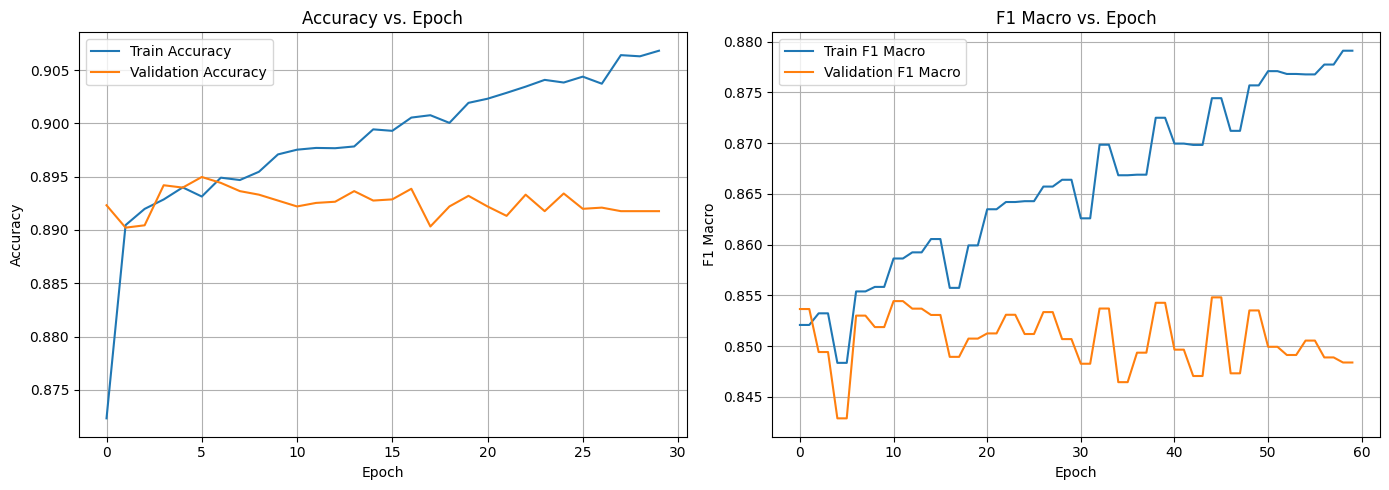

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (Modelo con Embeddings):

              precision    recall  f1-score   support

       <=50K       0.91      0.95      0.93      6803
        >50K       0.82      0.72      0.77      2242

    accuracy                           0.89      9045
   macro avg       0.87      0.83      0.85      9045
weighted avg       0.89      0.89      0.89      9045



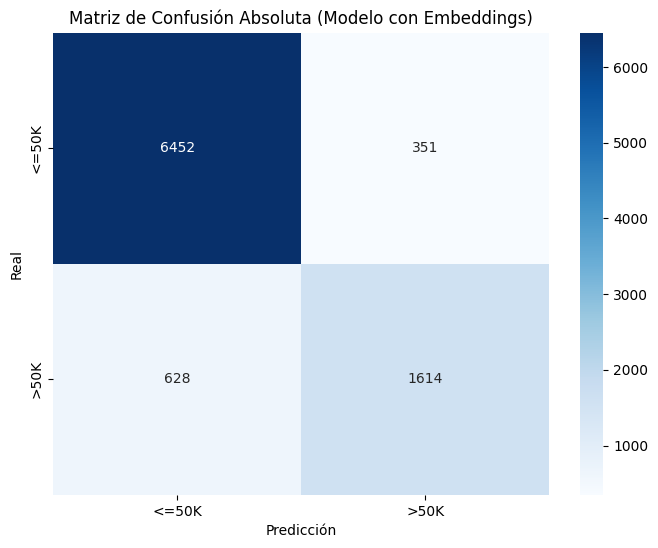

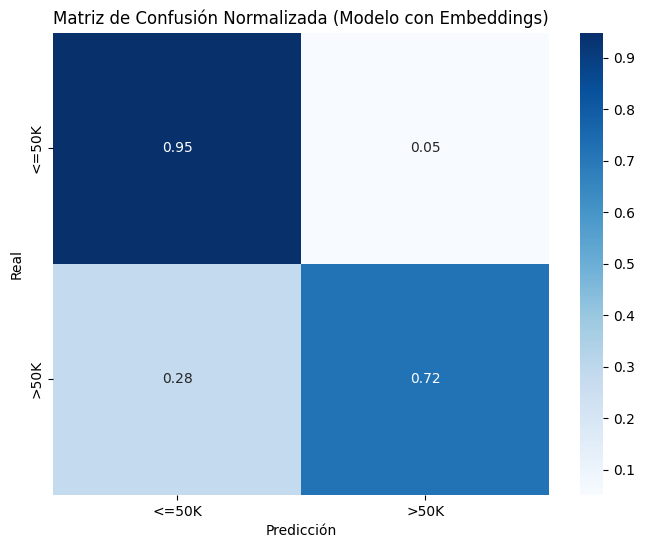

In [28]:
# Función para graficar accuracy y F1 Macro
def plot_metrics(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Accuracy vs. Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Plot F1 Macro
    axes[1].plot(history.history['f1_macro'], label='Train F1 Macro')
    axes[1].plot(history.history['val_f1_macro'], label='Validation F1 Macro')
    axes[1].set_title('F1 Macro vs. Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Graficar las curvas de entrenamiento y validación
plot_metrics(history)

# Predecir en el conjunto de prueba
y_pred_proba = model_with_embeddings.predict(X_test_inputs)
y_pred = (y_pred_proba > 0.5).astype(int)

# Mostrar Classification Report
print("\nClassification Report (Modelo con Embeddings):\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Mostrar Matriz de Confusión Absoluta
cm_absolute = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Absoluta (Modelo con Embeddings)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Mostrar Matriz de Confusión Normalizada por Fila
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Normalizada (Modelo con Embeddings)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


In [29]:
# Para comparar en punto D
report_embeddings = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

El modelo basado en embeddings alcanzó un desempeño general que es satisfactorio, con una accuracy del 89% y un F1 Macro de 0.85 sobre el conjunto de validación. (La diferencia entre las métricas es relativamente baja)

Los resultados muestran un buen desempeño para la clase mayoritaria (<=50K), mientras que la clase minoritaria (>50K) presenta un recall inferior, indicando que parte de los individuos con ingresos superiores a 50K son clasificados como pertenecientes al grupo de menores ingresos. Este comportamiento es consistente con el desbalance existente en el dataset y justifica el análisis mediante métricas adicionales a la accuracy.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

## Implementación del modelo sin embeddings

In [30]:
# Separar variables
X = df.drop('income', axis=1)
y = df['income']

# Codificar la variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Variables categóricas para One-Hot Encoding
# Acá estamos sumando los campos que en el punto b usamos embeding

one_hot_features = [
    'workclass',
    'marital-status',
    'relationship',
    'race',
    'sex',
    'occupation',
    'skill-profile',
    'native-country'
]

# Variable categórica con orden intrínseco
ordinal_features = ['education']

# Orden definido para education
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th',
    '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm',
    'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

In [31]:
# Separar los datos en entrenamiento y validación
X_train_ohe_raw, X_val_ohe_raw, y_train_ohe, y_val_ohe = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Preprocesamiento de variables numéricas y categóricas
preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_features),
        ('cat_ordinal', OrdinalEncoder(categories=[education_order]), ordinal_features)
    ],
    remainder='drop'
)

In [33]:
# Ajustar el preprocesador únicamente con los datos de entrenamiento
X_train_ohe_array = preprocessor_ohe.fit_transform(X_train_ohe_raw).toarray()
X_val_ohe_array = preprocessor_ohe.transform(X_val_ohe_raw).toarray()

# Obtener los nombres de las columnas generadas
onehot_feature_names = preprocessor_ohe.named_transformers_['cat_onehot'].get_feature_names_out(one_hot_features)
processed_column_names = numerical_features + onehot_feature_names.tolist() + ordinal_features

# Convertir a DataFrame para ver su estrucutra
X_train_ohe = pd.DataFrame(
    X_train_ohe_array,
    columns=processed_column_names,
    index=X_train_ohe_raw.index
)

X_val_ohe = pd.DataFrame(
    X_val_ohe_array,
    columns=processed_column_names,
    index=X_val_ohe_raw.index
)

display(X_train_ohe.head())

print(f"Shape de X_train_ohe: {X_train_ohe.shape}")
print(f"Shape de X_val_ohe: {X_val_ohe.shape}")
print(f"Shape de y_train_ohe: {y_train_ohe.shape}")
print(f"Shape de y_val_ohe: {y_val_ohe.shape}")

,age,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,skill-profile_accounting_bookkeeping,skill-profile_accounting_payroll,skill-profile_admin_document_control,skill-profile_admin_procurement_support,skill-profile_agriculture_field_work,skill-profile_automotive_repair,skill-profile_business_reporting_basic,skill-profile_caregiving_home_support,skill-profile_community_program_coordination,skill-profile_consulting_process_improvement,skill-profile_customer_service_hospitality,skill-profile_customer_service_retail,skill-profile_customer_success_operations,skill-profile_delivery_local_routes,skill-profile_education_classroom_teaching,skill-profile_education_curriculum_design,skill-profile_education_research_methods,skill-profile_education_teaching_assistant,skill-profile_engineering_drafting,skill-profile_engineering_quality_assurance,skill-profile_engineering_systems_design,skill-profile_entrepreneurship_business_development,skill-profile_entrepreneurship_small_business,skill-profile_executive_decision_support,skill-profile_facilities_maintenance,skill-profile_finance_budget_tracking,skill-profile_finance_financial_analysis,skill-profile_finance_investment_analysis,skill-profile_finance_risk_assessment,skill-profile_food_service_kitchen_basic,skill-profile_healthcare_clinical_coordination,skill-profile_healthcare_medical_assistant,skill-profile_healthcare_patient_support,skill-profile_healthcare_records_compliance,skill-profile_legal_case_management,skill-profile_legal_office_support,skill-profile_logistics_dispatch_coordination,skill-profile_logistics_forklift_operation,skill-profile_logistics_warehouse_basic,skill-profile_maintenance_janitorial,skill-profile_management_operations,skill-profile_management_people_operations,skill-profile_management_project_coordination,skill-profile_management_strategic_planning,skill-profile_management_team_lead,skill-profile_manufacturing_assembly,skill-profile_manufacturing_quality_control,skill-profile_office_data_entry_basic,skill-profile_office_records_management,skill-profile_office_spreadsheets_advanced,skill-profile_office_spreadsheets_basic,skill-profile_personal_care_assistance,skill-profile_protective_services_coordination,skill-profile_public_sector_administration,skill-profile_real_estate_sales_support,skill-profile_research_scientific_writing,skill-profile_research_statistical_analysis,skill-profile_sales_account_management,skill-profile_sales_crm_advanced,skill-profile_sales_crm_basic,skill-profile_sales_retail_basic,skill-profile_security_patrol_basic,skill-profile_tech_cloud_systems,skill-profile_tech_computer_literacy,skill-profile_tech_cybersecurity,skill-profile_tech_data_analysis,skill-profile_tech_database_support,skill-profile_tech_network_support,skill-profile_tech_programming_advanced,skill-profile_tech_programming_basic,skill-profile_tech_software_engineering,skill-profile_tech_sql_reporting,skill-profile_tech_web_support,skill-profile_trade_cnc_operation,skill-profile_trade_construction_basic,skill-profile_trade_electrical,skill-profile_t

Shape de X_train_ohe: (36177, 167)
Shape de X_val_ohe: (9045, 167)
Shape de y_train_ohe: (36177,)
Shape de y_val_ohe: (9045,)


In [34]:
# Entrada única
input_layer = keras.Input(
    shape=(X_train_ohe.shape[1],),
    name="input_features"
)

# Capas ocultas (misma que el punto b)
# pero SIN dropout

x = layers.Dense(128, activation="relu")(input_layer)
x = layers.Dense(64, activation="relu")(x)

# Salida
output_layer = layers.Dense(1, activation="sigmoid")(x)

# Modelo
model_onehot = Model(
    inputs=input_layer,
    outputs=output_layer
)

model_onehot.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_onehot.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 167)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,825 (116.50 KB)

 Trainable params: 29,825 (116.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Preparar las entradas del modelo
X_train_inputs = X_train_ohe.values.astype("float32")
X_val_inputs = X_val_ohe.values.astype("float32")

# Preparar la variable objetivo
y_train_inputs = y_train_ohe.reshape(-1, 1).astype("float32")
y_val_inputs = y_val_ohe.reshape(-1, 1).astype("float32")

print(f"Shape de X_train_inputs: {X_train_inputs.shape}")
print(f"Shape de X_val_inputs: {X_val_inputs.shape}")
print(f"Shape de y_train_inputs: {y_train_inputs.shape}")
print(f"Shape de y_val_inputs: {y_val_inputs.shape}")

Shape de X_train_inputs: (36177, 167)
Shape de X_val_inputs: (9045, 167)
Shape de y_train_inputs: (36177, 1)
Shape de y_val_inputs: (9045, 1)


In [36]:
# Inicializar Callback
f1_callback_ohe = F1MacroHistory(
    train_data=(X_train_inputs, y_train_inputs),
    val_data=(X_val_inputs, y_val_inputs)
)

# Entrenar el modelo
history_onehot = model_onehot.fit(
    X_train_inputs,
    y_train_inputs,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_inputs, y_val_inputs),
    callbacks=[f1_callback_ohe],
    verbose=1
)

Epoch 1/30
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8357 - loss: 0.3507 — f1_macro: 0.8511 — val_f1_macro: 0.8447
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8706 - loss: 0.2906 - val_accuracy: 0.8887 - val_loss: 0.2579 - f1_macro: 0.8511 - val_f1_macro: 0.8447
Epoch 2/30
1113/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8907 - loss: 0.2569 — f1_macro: 0.8547 — val_f1_macro: 0.8476
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8897 - loss: 0.2572 - val_accuracy: 0.8908 - val_loss: 0.2588 - f1_macro: 0.8547 - val_f1_macro: 0.8476
Epoch 3/30
1122/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8953 - loss: 0.2504 — f1_macro: 0.8579 — val_f1_macro: 0.8494
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8933 - loss: 0.2509 - val_accuracy: 0.8900 - val_loss: 0.2577 - f1_macro: 0.8579 - val_f1_macro: 0.8494
Epoch 4/30
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8982 - loss: 0.2423 — f1_macro: 0.8620 — val_f1_macro: 0.8

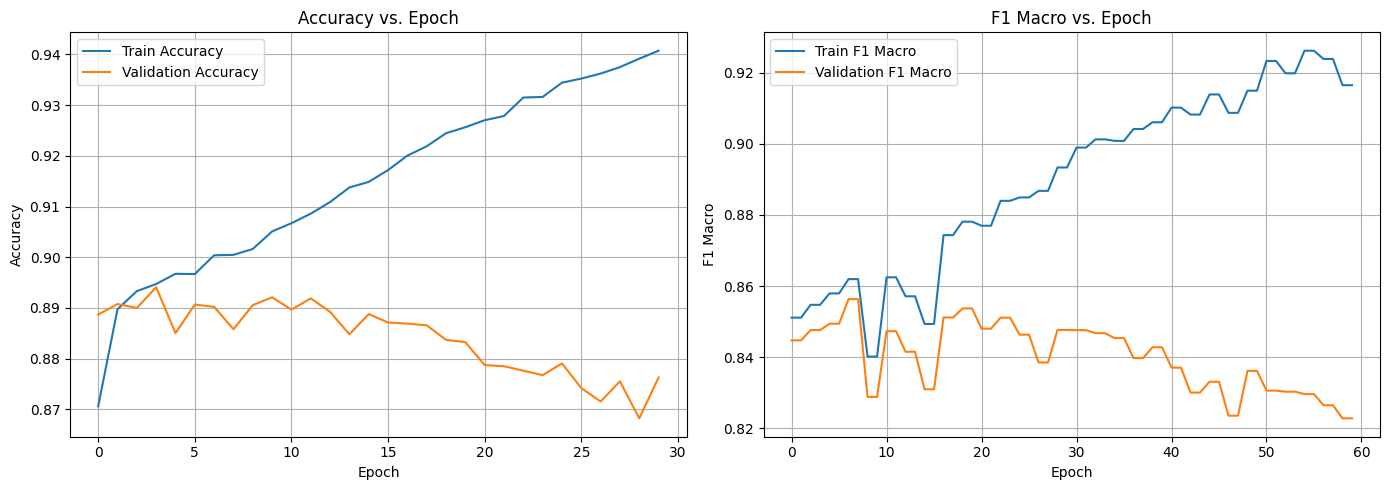

In [37]:
plot_metrics(history_onehot)



In [38]:
y_pred_proba_onehot = model_onehot.predict(X_val_inputs)
y_pred_onehot = (y_pred_proba_onehot > 0.5).astype(int)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



Classification Report (Modelo One-Hot):

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      6803
        >50K       0.81      0.66      0.73      2242

    accuracy                           0.88      9045
   macro avg       0.85      0.80      0.82      9045
weighted avg       0.87      0.88      0.87      9045



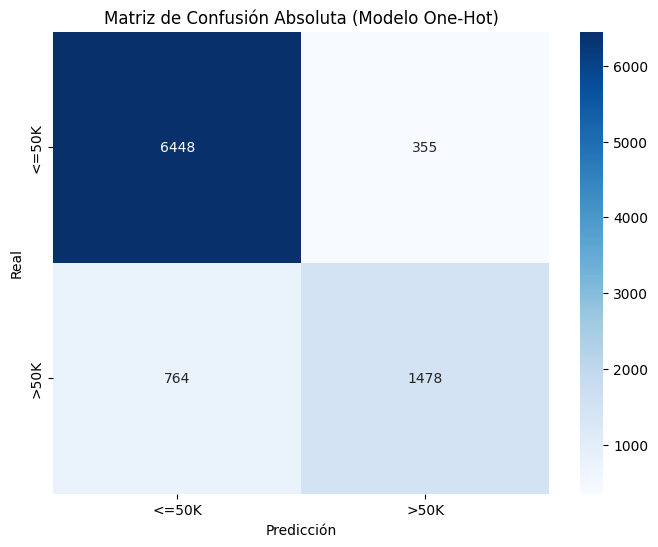

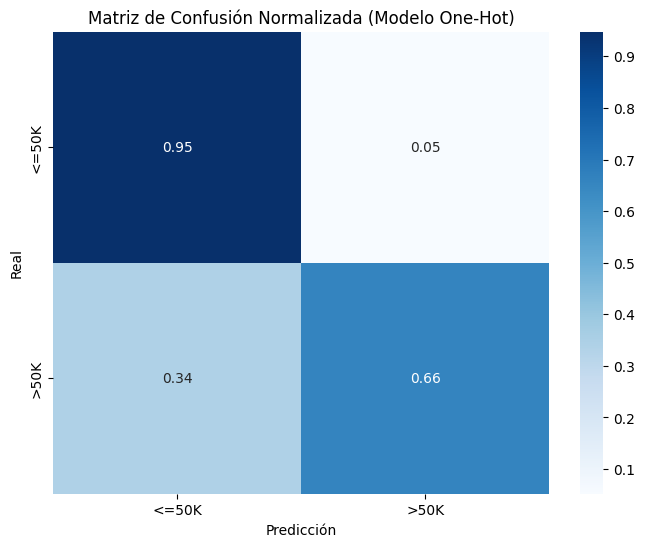

In [39]:
# Classification Report
print("\nClassification Report (Modelo One-Hot):\n")
print(
    classification_report(
        y_val_ohe,
        y_pred_onehot,
        target_names=label_encoder.classes_
    )
)

# Matriz de Confusión Absoluta
cm_absolute_onehot = confusion_matrix(y_val_ohe, y_pred_onehot)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_absolute_onehot,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusión Absoluta (Modelo One-Hot)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Matriz de Confusión Normalizada
cm_normalized_onehot = confusion_matrix(
    y_val_ohe,
    y_pred_onehot,
    normalize='true'
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized_onehot,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusión Normalizada (Modelo One-Hot)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [40]:
# Para comparar en punto D
report_onehot = classification_report(
    y_val_ohe,
    y_pred_onehot,
    target_names=label_encoder.classes_,
    output_dict=True
)

El modelo basado en One-Hot sin embeding obtuvo un desempeño que alcanza una accuracy de 0.87 y un F1 Macro de 0.83 sobre el conjunto de validación.

El modelo logró un buen rendimiento para la clase mayoritaria (<=50K), aunque presentó una menor capacidad de detección para la clase >50K, debido al desbalance en las categorías ya mencionado.

## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

In [43]:
model_with_embeddings.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ occupation_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill-profile_input │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ native-country_inp… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ occupation_embeddi… │ (None, 1, 7)      │        105 │ occupation_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill-profile_embe… │ (None, 1, 40)     │      3,240 │ skill-profile_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ native-country_emb… │ (None, 1, 21)     │        882 │ native-country_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_cat_input       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7)         │          0 │ occupation_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 40)        │          0 │ skill-profile_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 21)        │          0 │ native-country_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ num_cat_input[0]… │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 76,430 (298.56 KB)

 Trainable params: 25,476 (99.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,954 (199.04 KB)

In [42]:
model_onehot.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 167)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,477 (349.52 KB)

 Trainable params: 29,825 (116.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,652 (233.02 KB)

A continuación, se presenta una tabla comparativa con los resultados obtenidos durante el entrenamiento y validación de ambos modelos: el modelo con embeddings desarrollado en el punto B y el modelo basado únicamente en One-Hot Encoding desarrollado en el punto C.

## Tabla Comparativa de Resultados

| Característica / Métrica | Modelo con Embeddings (Parte B) | Modelo sin Embeddings - One-Hot Encoding (Parte C) |
| :--- | :---: | :---: |
| Representación de variables categóricas | Embeddings para `occupation`, `skill-profile` y `native-country` + One-Hot + Ordinal | One-Hot Encoding para todas las variables categóricas + Ordinal |
| Cantidad de entradas del modelo | 4 entradas independientes (variables procesadas + 3 entradas de embeddings) | 1 entrada única consolidada |
| Dimensión de entrada del modelo | Menor dimensionalidad debido a la reducción mediante embeddings | 167 características generadas por la expansión One-Hot |
| Parámetros entrenables | Completar según `model.summary()` | Completar según `model.summary()` |
| Regularización interna | Dropout (0.3) en capas ocultas | Sin capas Dropout |
| Accuracy en validación | **0.89** | **0.87** |
| F1 Macro en validación | **0.85** | **0.83** |
| F1-score clase >50K | **0.77** | **0.74** |


## Análisis y Observaciones Detalladas

### 1. Diferencia en la representación de variables categóricas

El modelo con embeddings obtuvo un mejor desempeño general respecto al modelo basado únicamente en One-Hot Encoding. La principal diferencia entre ambos enfoques se encuentra en la forma de representar las variables categóricas de alta cardinalidad.

En el modelo con embeddings, las variables `occupation`, `skill-profile` y `native-country` fueron transformadas en vectores densos de menor dimensión, permitiendo que la red neuronal aprenda representaciones internas de las categorías durante el entrenamiento.

Por otro lado, el modelo One-Hot Encoding representa cada categoría como una nueva variable binaria independiente. Si bien este método conserva la información original, aumenta la cantidad de dimensiones de entrada y no permite capturar relaciones entre categorías similares.

### 2. Impacto en el desempeño predictivo

El modelo con embeddings logró una mejora moderada pero consistente, alcanzando una accuracy de **0.89** frente a **0.87** del modelo One-Hot. La diferencia también se observa en el F1 Macro (**0.85** frente a **0.83**), indicando una mejor capacidad de clasificación considerando ambas clases.

La mejora más importante aparece en la clase minoritaria (`>50K`), donde el modelo con embeddings obtuvo un F1-score de **0.77**, mientras que el modelo One-Hot alcanzó **0.74**. Esto indica que las representaciones aprendidas mediante embeddings ayudaron a identificar patrones asociados a individuos con mayores ingresos.

### 3. Complejidad y capacidad de generalización

Aunque el modelo One-Hot posee una arquitectura más simple y una única entrada, la representación generada es más dispersa debido al aumento de variables producido por la codificación categórica.

El modelo con embeddings, además de reducir la dimensionalidad de las variables de alta cardinalidad, incorporó capas Dropout que ayudaron a reducir el sobreajuste y mejorar la capacidad de generalización sobre datos no observados.

En conclusión, para este problema los embeddings resultaron una alternativa más eficiente, ya que permitieron representar variables categóricas complejas mediante espacios reducidos y mejorar ligeramente el rendimiento predictivo respecto al enfoque tradicional basado en One-Hot Encoding.